# Fashion Mnist ewaluacja

Ten notebook jest przeznaczony do badania algorytmów na zbiorze **Fashion_Mnist**

Zbiór Fashion-Mnist jest standardowym zbiorem w computer vision (Hello World w świece CV)


In [1]:
import tensorflow_datasets as tfds

## Loading data

In [2]:
import torch

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

transform = transforms.Compose([

    transforms.ToTensor()

])

# LDA

In [3]:
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

In [8]:
from utils.lda import my_lda
lda = my_lda(n_components=2)

X_lda, df_lda = lda.fit(X_train_scaled, y_train)


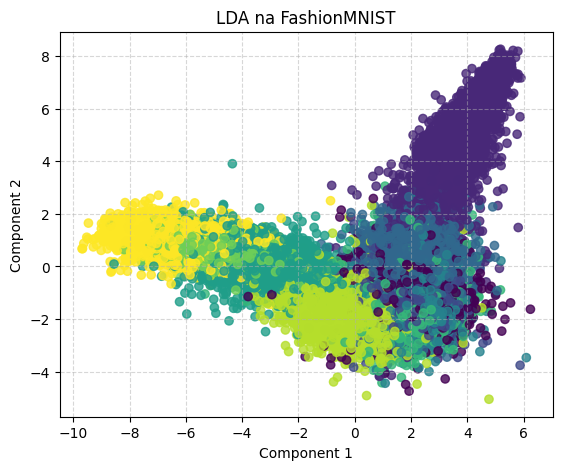

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_lda[:,0], X_lda[:,1], c=y_train, alpha=0.8)
plt.title("LDA na FashionMNIST")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [18]:
from sklearn.manifold import trustworthiness

idx = np.random.choice(len(X_train_scaled), 5000, replace=False)

trust_lda = trustworthiness(
    X_train_scaled[idx],
    X_lda[idx],
    n_neighbors=5
)

print(f"Trustworthiness dla LDA: {trust_lda:.4f}")

Trustworthiness dla LDA: 0.7810


In [22]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=1,
    n_init=10
)

clusters = kmeans.fit_predict(X_lda)

nmi_pca = normalized_mutual_info_score(
    y_train[idx],
    clusters[idx]
)

sil_pca = silhouette_score(
    X_lda[idx],
    clusters[idx]
)

cal_har = calinski_harabasz_score(
    X_lda[idx],
    clusters[idx]
)
print(f"NMI dla LDA: {nmi_pca:.4f}")
print(f"Silhouette dla LDA: {sil_pca:.4f}")
print(f"Calinski-Harabasz dla LDA: {cal_har:.4f}")

NMI dla LDA: 0.5468
Silhouette dla LDA: 0.4087
Calinski-Harabasz dla LDA: 16343.5842


# PCA

In [15]:
from utils.pca import my_pca
import pandas as pd
import sys
sys.modules['utils.pca'].pd = pd

pca = my_pca(n_components=2)

X_pca, df_pca = pca.fit(X_train_scaled)

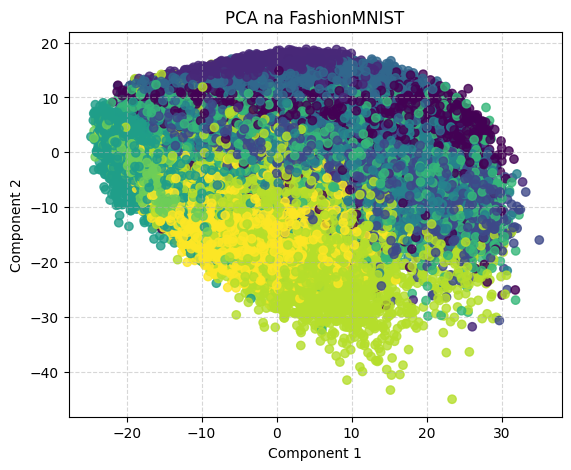

In [16]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, alpha=0.8)
plt.title("PCA na FashionMNIST")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [19]:
trust_pca = trustworthiness(
    X_train_scaled[idx],
    X_pca[idx],
    n_neighbors=5
)

print(f"Trustworthiness dla PCA: {trust_pca:.4f}")

Trustworthiness dla PCA: 0.8703


In [21]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=1,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

nmi_pca = normalized_mutual_info_score(
    y_train[idx],
    clusters[idx]
)

sil_pca = silhouette_score(
    X_pca[idx],
    clusters[idx]
)

cal_har = calinski_harabasz_score(
    X_pca[idx],
    clusters[idx]
)
print(f"NMI dla PCA: {nmi_pca:.4f}")
print(f"Silhouette dla PCA: {sil_pca:.4f}")
print(f"Calinski-Harabasz dla PCA: {cal_har:.4f}")

NMI dla PCA: 0.4129
Silhouette dla PCA: 0.3965
Calinski-Harabasz dla PCA: 6075.1656
